In [74]:
# Lab08 - Matthew Woods

import numpy as np, xarray as xr, matplotlib.pyplot as plt

## Task 1:

In [81]:
# --- Setup (given) ---
rng   = np.random.default_rng(42)
lats_f = np.arange(25, 50, 0.25)
lons_f = np.arange(-120, -70, 0.25)
LON, LAT = np.meshgrid(lons_f, lats_f)
storm  = 30 * np.exp(-((LAT - 37)**2 / 3 + (LON + 100)**2 / 3))
precip = storm + 0.5 + rng.exponential(0.3, storm.shape)
ds_fine = xr.Dataset({'precip': (['lat','lon'], precip, {'units':'mm/day'})},
                      coords={'lat': lats_f, 'lon': lons_f})


# Bilinear regrid to 1°
lats_c = np.arange(25.5, 50, 1.0)
lons_c = np.arange(-119.5, -70, 1.0)
ds_bil = ds_fine.interp(lat=lats_c, lon=lons_c)


# --- Your turn ---
# Area weights:  cos(lat) * dlat_deg * dlon_deg
w_f = np.cos(np.radians(ds_fine.lat)) * 0.25 * 0.25   # shape (lat,)
w_c = np.cos(np.radians(ds_bil.lat)) # Same as above but do it for the interpolated grid. Now the degree size is just 1 so I don't need the resizing 0.25 factors


# Define Variables for Mass, Min Max, Mean,
mass_fine = float((ds_fine['precip'] * w_f).sum())
mass_bil  = float((ds_bil['precip'] * w_c).sum()) # Find mass using the new weights

mean_fine = float(ds_fine['precip'].mean()) 
mean_bil = float(ds_bil['precip'].mean()) 

min_fine = float(ds_fine['precip'].min())
min_bil = float(ds_bil['precip'].min())

max_fine = float(ds_fine['precip'].max())
max_bil = float(ds_bil['precip'].max())


# Masses
print(f"Mass Original: {mass_fine}")
print(f"Mass Regridded: {mass_bil}")
print(f"Mass Error: {(mass_bil - mass_fine) / mass_fine * 100:.3f}%")
print("------------------------------------")

# Means
print(f"Mean Original: {mean_fine}")
print(f"Mean Regridded: {mean_bil}")
print(f"Mean Error: { (mean_bil - mean_fine) / mean_fine * 100:.3f}%")
print("------------------------------------")

# Mins
print(f"Min Original: {min_fine}") # Print the min precipitations
print(f"Min Regridded: {min_bil}")
print(f"Min Error:{ (min_bil - min_fine) / min_fine * 100:.3f}%") # (min_bil - min_fine) / min_fine
print("------------------------------------")

# Maxes
print(f"Max Original: {max_fine}") # Print the max precipitations
print(f"Max Regridded: {max_bil}")
print(f"Max Error:{ (max_bil - max_fine) / max_fine * 100:.3f}%")
print("------------------------------------")

# Look at NaN Count
print(f"NaNs: {int(ds_bil['precip'].isnull().sum())}") # I looked at the notation within the lab key for this line because I wasn't sure how to filter for NaN values
# The code takes the values, looks for NaNs with isnull(), then sums them up with .sum() and converts to an integer
# I found 0 NaNs, which is good
print("------------------------------------")

# Find Fraction of Mass Lost or Gained
# This is the mass error value from earlier
print(f"The fraction of mass gained through this process of regridding was {(mass_bil - mass_fine) / mass_fine * 100:.3f}%.") # Plugging in % mass error here

Mass Original: 1013.2196677213853
Mass Regridded: 1017.9293221649305
Mass Error: 0.465%
------------------------------------
Mean Original: 1.025343861840249
Mean Regridded: 1.0318596043834147
Mean Error: 0.635%
------------------------------------
Min Original: 0.5000213678473355
Min Regridded: 0.5009147151978309
Min Error:0.179%
------------------------------------
Max Original: 30.59093403089655
Max Regridded: 26.32143666046639
Max Error:-13.957%
------------------------------------
NaNs: 0
------------------------------------
The fraction of mass gained through this process of regridding was 0.465%.


## Task 2:

1D mass error: 0.000000%


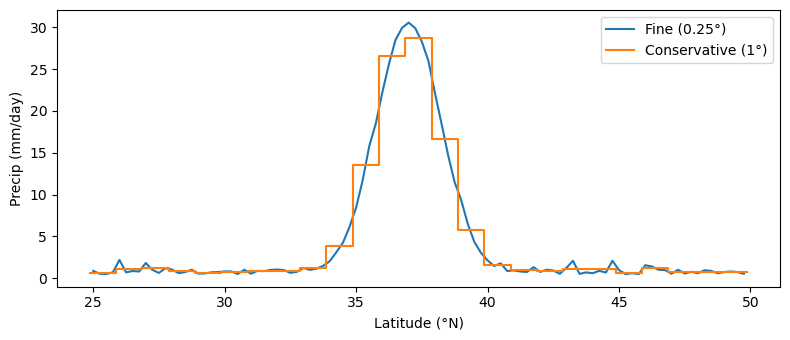

In [78]:
# Task 2

def conservative_regrid_1d(f_src, src_edges, tgt_edges):
    """
    f_src:     source values  (n_src,)
    src_edges: source cell boundaries  (n_src + 1,)
    tgt_edges: target cell boundaries  (n_tgt + 1,)
    Returns:   target values  (n_tgt,)
    """
    n_tgt = len(tgt_edges) - 1
    out   = np.zeros(n_tgt)
    for i in range(n_tgt):
        t0, t1 = tgt_edges[i], tgt_edges[i + 1]
        # loop over source cells, accumulate weighted contributions
        for k in range(len(f_src)):
            s0, s1 = src_edges[k], src_edges[k + 1]
            
            # As I understand the hint, the code here takes the max(0,difference) so that the value of overlap is always 0 / positive. Inside it looks at the difference between the the smallest of
            # the big edge (i+1) and biggest of the small edge (i) (from source and target cells). 
            # This gives anything where the largest of small cell and smallest of large cell could overlap with each other and then gets weighted based on the overlap

            overlap = max(0, min(s1,t1) - max(s0,t0))           # length of [s0,s1] ∩ [t0,t1]
            

            out[i] += f_src[k] * overlap
        out[i] /= (t1 - t0)       # normalize by target cell width
    return out

# --- Test scaffold (given) ---
lon_idx   = np.argmin(np.abs(lons_f - (-100)))
f_src     = ds_fine['precip'].values[:, lon_idx]

src_dlat  = float(lats_f[1] - lats_f[0])
src_edges = np.append(lats_f - src_dlat / 2, lats_f[-1] + src_dlat / 2)
tgt_edges = np.arange(src_edges[0], src_edges[-1] + 0.001, 1.0)

f_tgt = conservative_regrid_1d(f_src, src_edges, tgt_edges) # This calls the function and regrids the values

# Mass check — should be 0.000000%
mass_before = np.sum(f_src * np.diff(src_edges))
mass_after  = np.sum(f_tgt * np.diff(tgt_edges))
print(f"1D mass error: {(mass_after - mass_before) / mass_before * 100:.6f}%")

# Plot: overlay fine (0.25°) and conservative (1°) profiles
tgt_ctrs = 0.5 * (tgt_edges[:-1] + tgt_edges[1:])
fig, ax  = plt.subplots(figsize=(8, 3.5))


# fine grid line
ax.plot(lats_f, f_src, label='Fine (0.25°)') # Plot latitudes, source values of precipitation for all lat indexes and at lon_idx specified above

# coarse step plot
# I was a bit confused here trying to plot the values of latitude with the target values of precipitation since there is no lats variable for the target grid that I see. 
# I tried to plot tgt_edges and f_tgt but the shapes were different (26 vs 25)
# After trying for a bit, I looked at the lab answer to get help in how to approach this plot
# I found that the shape issue was solved by adding on the last value to the original array for the f_tgt
# The key also had the line np.append(tgt_edges[:-1],tgt_edges[-1]) but I don't think this changes the array at all because it just adds the last value on the array missing that value so I used tgt_edges
ax.step(tgt_edges, np.append(f_tgt, f_tgt[-1]), label='Conservative (1°)', where='post')
# The key also used where='post' to align where the stepping happens so I added that in as well to make the plot make more visual sense


ax.set_xlabel('Latitude (°N)');  ax.set_ylabel('Precip (mm/day)') # This tells me to plot the latitude, precipitation values
ax.legend();  plt.tight_layout();  plt.show()